# Klasifikasi Tingkat Kematangan Buah Stroberi Berbasis Citra Menggunakan Convolutional Neural Network (CNN)

Notebook ini membandingkan dua model *transfer learning*, yaitu **MobileNetV3-Large** dan **EfficientNetB0**, untuk mengklasifikasikan citra stroberi menjadi kelas *halfripe*, *ripe*, dan *unripe*.

Alur implementasi mengikuti flowchart penelitian:

1. Data preparation
2. Data splitting
3. Load pre-trained model
4. Train the model
5. Validate the model
6. Testing, evaluasi metrik, dan perbandingan performa

**Nama:** Athaya Sandiarta Nura Alfelarizi  
**NIM:** 1301210002


In [ ]:
# 1. IMPORT LIBRARY
# Library berikut digunakan untuk pengelolaan file, pengolahan data,
# visualisasi, pelatihan model TensorFlow/Keras, serta evaluasi klasifikasi.

import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)


In [ ]:
# 1.1 REPRODUCIBILITY
# Seed dibuat tetap agar pembagian data dan proses pelatihan lebih konsisten
# ketika notebook dijalankan ulang.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# 2. DATA PREPARATION — MOUNT DRIVE DAN MENENTUKAN LOKASI DATASET

from google.colab import drive
drive.mount("/content/drive")

DATASET_DIR = Path("/content/drive/MyDrive/TA_1301210002/strawberry_dataset")
WORK_DIR = Path("/content/strawberry_workdir")
SPLIT_DIR = WORK_DIR / "split_dataset"

# Urutan kelas harus konsisten pada seluruh proses training, validasi, dan testing.
CLASS_NAMES = ["halfripe", "ripe", "unripe"]
LABEL_ID = {
    "halfripe": "Setengah Matang",
    "ripe": "Matang",
    "unripe": "Mentah",
}
class_labels = [LABEL_ID[class_name] for class_name in CLASS_NAMES]


Mounted at /content/drive


In [ ]:
# 2.1 MEMERIKSA JUMLAH CITRA PER KELAS
# Pemeriksaan ini memastikan setiap folder kelas tersedia dan berisi citra

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def list_images(folder):
    # Mengembalikan daftar file citra yang valid pada satu folder kelas.
    return [
        path for path in folder.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

counts = {
    class_name: len(list_images(DATASET_DIR / class_name))
    for class_name in CLASS_NAMES
}

print("Jumlah citra pada dataset asli:")
for class_name, count in counts.items():
    print(f"- {LABEL_ID[class_name]} ({class_name}): {count} citra")


Jumlah citra pada dataset asli:
- Setengah Matang (halfripe): 500 citra
- Matang (ripe): 500 citra
- Mentah (unripe): 500 citra


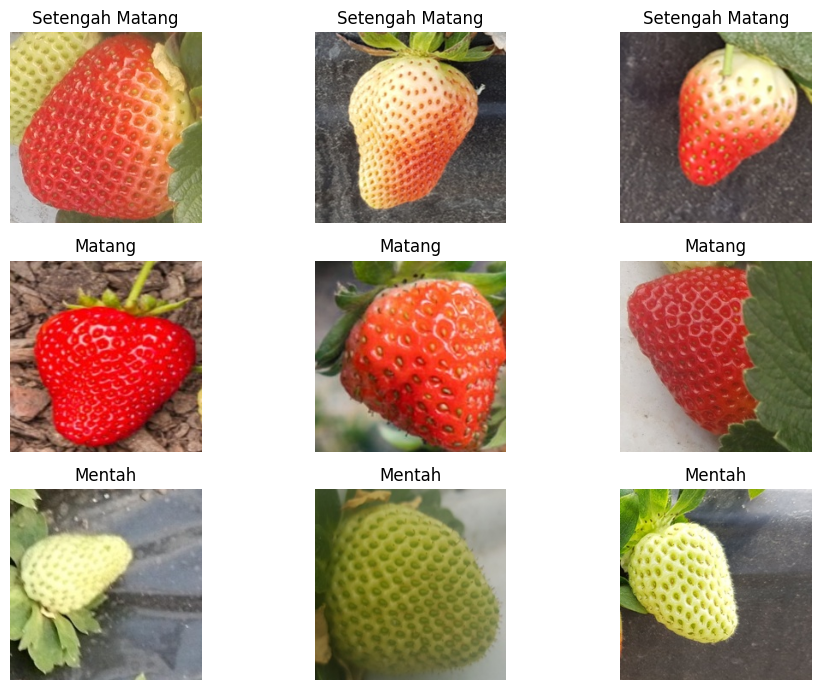

In [ ]:
# 2.2 MENAMPILKAN CONTOH CITRA
# Visualisasi sampel membantu memverifikasi bahwa citra dan label sudah sesuai.

plt.figure(figsize=(10, 7))
plot_index = 1

for class_name in CLASS_NAMES:
    image_files = list_images(DATASET_DIR / class_name)
    sample_files = random.sample(image_files, k=min(3, len(image_files)))

    for image_path in sample_files:
        image = plt.imread(image_path)
        plt.subplot(len(CLASS_NAMES), 3, plot_index)
        plt.imshow(image)
        plt.title(LABEL_ID[class_name])
        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

In [ ]:
# 2.3 PARAMETER EKSPERIMEN
# Parameter ini digunakan secara sama untuk kedua model agar perbandingan adil.

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 70
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.4
LABEL_SMOOTHING = 0.05

# Rasio data: 70% training, 15% validation, dan 15% testing.
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
AUTOTUNE = tf.data.AUTOTUNE


In [ ]:
# 3. DATA SPLITTING
# Dataset dibagi per kelas menjadi training, validation, dan testing.
# Data test tidak digunakan pada proses training maupun pemilihan model.

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

for split_name in ["train", "val", "test"]:
    for class_name in CLASS_NAMES:
        (SPLIT_DIR / split_name / class_name).mkdir(parents=True, exist_ok=True)

for class_name in CLASS_NAMES:
    files = list_images(DATASET_DIR / class_name)
    random.shuffle(files)

    n_total = len(files)
    n_train = int(n_total * TRAIN_RATIO)
    n_val = int(n_total * VAL_RATIO)
    split_files = {
        "train": files[:n_train],
        "val": files[n_train:n_train + n_val],
        "test": files[n_train + n_val:],
    }

    for split_name, paths in split_files.items():
        for source_path in paths:
            destination_path = SPLIT_DIR / split_name / class_name / source_path.name
            shutil.copy2(source_path, destination_path)

print("Jumlah citra setelah data splitting:")
for split_name in ["train", "val", "test"]:
    print(f"\n{split_name.upper()}")
    for class_name in CLASS_NAMES:
        print(f"{class_name}: {len(list_images(SPLIT_DIR / split_name / class_name))}")


Jumlah citra setelah data splitting:

TRAIN
halfripe: 350
ripe: 350
unripe: 350

VAL
halfripe: 75
ripe: 75
unripe: 75

TEST
halfripe: 75
ripe: 75
unripe: 75


In [ ]:
# 4. MEMUAT DATASET UNTUK TRAINING, VALIDATION, DAN TESTING
# label_mode='categorical' menghasilkan label one-hot untuk klasifikasi 3 kelas.

train_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "val",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Prefetch menyiapkan batch berikutnya saat model memproses batch saat ini.
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Urutan kelas:", CLASS_NAMES)
print("Label Indonesia:", class_labels)

Found 1050 files belonging to 3 classes.
Found 225 files belonging to 3 classes.
Found 225 files belonging to 3 classes.
Urutan kelas: ['halfripe', 'ripe', 'unripe']
Label Indonesia: ['Setengah Matang', 'Matang', 'Mentah']


In [ ]:
# 5. DATA AUGMENTATION
# Augmentasi diterapkan hanya saat training untuk meningkatkan keragaman citra
# dan membantu model mengurangi risiko overfitting.

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.12),
        layers.RandomContrast(0.12),
    ],
    name="data_augmentation",
)


In [ ]:
# 6. MODEL 1 — LOAD PRE-TRAINED MOBILENETV3-LARGE
# Bobot ImageNet digunakan sebagai feature extractor (transfer learning).
# Seluruh layer dasar dibekukan (trainable=False), sedangkan classifier baru
# dilatih untuk tiga kelas tingkat kematangan stroberi.

def build_mobilenet_model(num_classes, input_shape):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = keras.applications.mobilenet_v3.preprocess_input(x)

    base_model = keras.applications.MobileNetV3Large(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="MobileNetV3Large")


In [ ]:
# 7. MODEL 2 — LOAD PRE-TRAINED EFFICIENTNETB0
# Struktur proses sama dengan Model 1 agar perbandingan dilakukan pada
# konfigurasi training dan dataset yang setara.

def build_efficientnet_model(num_classes, input_shape):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = keras.applications.efficientnet.preprocess_input(x)

    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="EfficientNetB0")


In [ ]:
# 8. KONFIGURASI TRAINING
# Fungsi ini menetapkan optimizer, loss, dan metrik yang digunakan oleh kedua model.

def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=["accuracy"],
    )
    return model

In [ ]:
# 9. TRAIN THE MODEL DAN VALIDATE THE MODEL
# Training memakai train_ds. Pada setiap epoch, val_ds digunakan untuk validasi.
# ModelCheckpoint menyimpan model dengan validation accuracy terbaik.

def train_and_validate_model(model_name, build_fn):
    print("=" * 60)
    print(f"Training dan validation: {model_name}")
    print("=" * 60)

    model = build_fn(num_classes=len(CLASS_NAMES), input_shape=IMG_SIZE + (3,))
    model = compile_model(model)

    checkpoint_path = WORK_DIR / f"best_{model_name}.keras"
    log_path = WORK_DIR / f"log_{model_name}.csv"
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1,
        ),
        keras.callbacks.CSVLogger(filename=str(log_path), append=False),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    # Hanya model terbaik berdasarkan validation accuracy yang diteruskan ke testing.
    best_model = keras.models.load_model(checkpoint_path)
    return best_model, history

In [ ]:
# 9.1 TRAINING DAN VALIDATION — MODEL 1: MOBILENETV3-LARGE
mobilenet_model, mobilenet_history = train_and_validate_model(
    model_name="MobileNetV3Large",
    build_fn=build_mobilenet_model,
)

Training dan validation: MobileNetV3Large
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/70
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3150 - loss: 1.9100
Epoch 1: val_accuracy improved from None to 0.25778, saving model to /content/strawberry_workdir/best_MobileNetV3Large.keras

Epoch 1: finished saving model to /content/strawberry_workdir/best_MobileNetV3Large.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 168ms/step - accuracy: 0.3419 - loss: 1.8105 - val_accuracy: 0.2578 - val_loss: 1.3783
Epoch 2/70
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4334 - loss: 1.4661
Epoch 2: val_accuracy improved from 0.25778 to 0.40889, saving model to /content/strawberry_workdir/best_MobileNetV3Large.keras

Epoch 2: finished saving model to /content/strawberry_workdir/best_MobileNetV3Large.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.4533 - loss: 1.4274 - val_accuracy: 0.4089 - val_loss: 1.1223
Epoch 3/70
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.522

In [ ]:
# 9.2 TRAINING DAN VALIDATION — MODEL 2: EFFICIENTNETB0
efficientnet_model, efficientnet_history = train_and_validate_model(
    model_name="EfficientNetB0",
    build_fn=build_efficientnet_model,
)

Training dan validation: EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/70
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4238 - loss: 1.5675
Epoch 1: val_accuracy improved from None to 0.52444, saving model to /content/strawberry_workdir/best_EfficientNetB0.keras

Epoch 1: finished saving model to /content/strawberry_workdir/best_EfficientNetB0.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 276ms/step - accuracy: 0.4400 - loss: 1.4720 - val_accuracy: 0.5244 - val_loss: 0.9801
Epoch 2/70
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5319 - loss: 1.1978
Epoch 2: val_accuracy improved from 0.52444 to 0.63556, saving model to /content/strawberry_workdir/best_EfficientNetB0.keras

Epoch 2: finished saving model to /content/strawberry_workdir/best_EfficientNetB0.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.5648 - loss: 1.1748 - val_accuracy: 0.6356 - val_loss: 0.8796
Epoch 3/70
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6483 - loss:

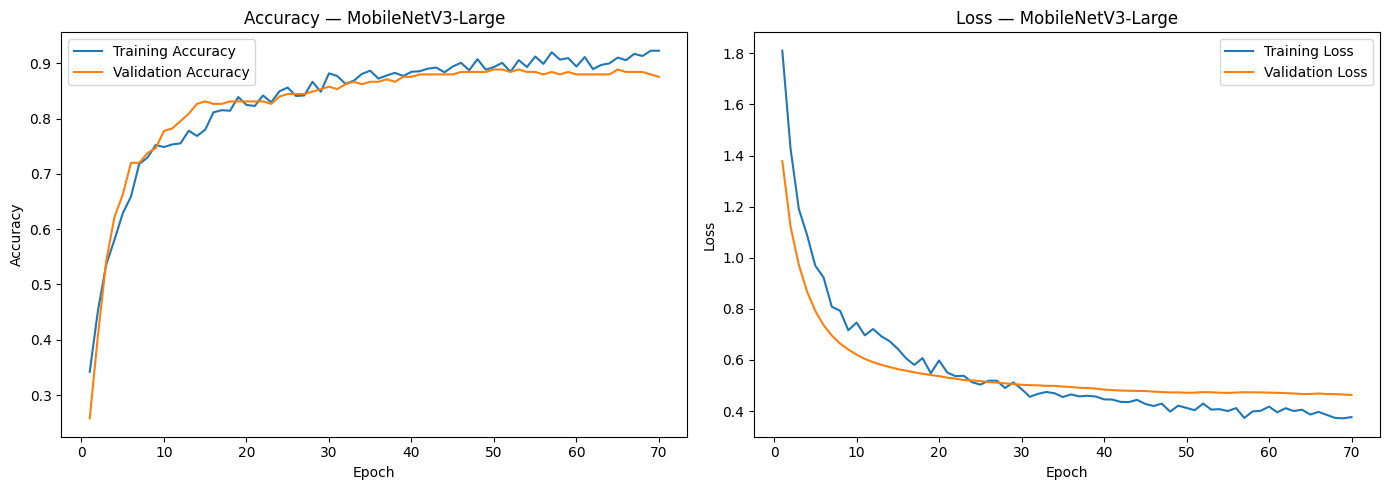

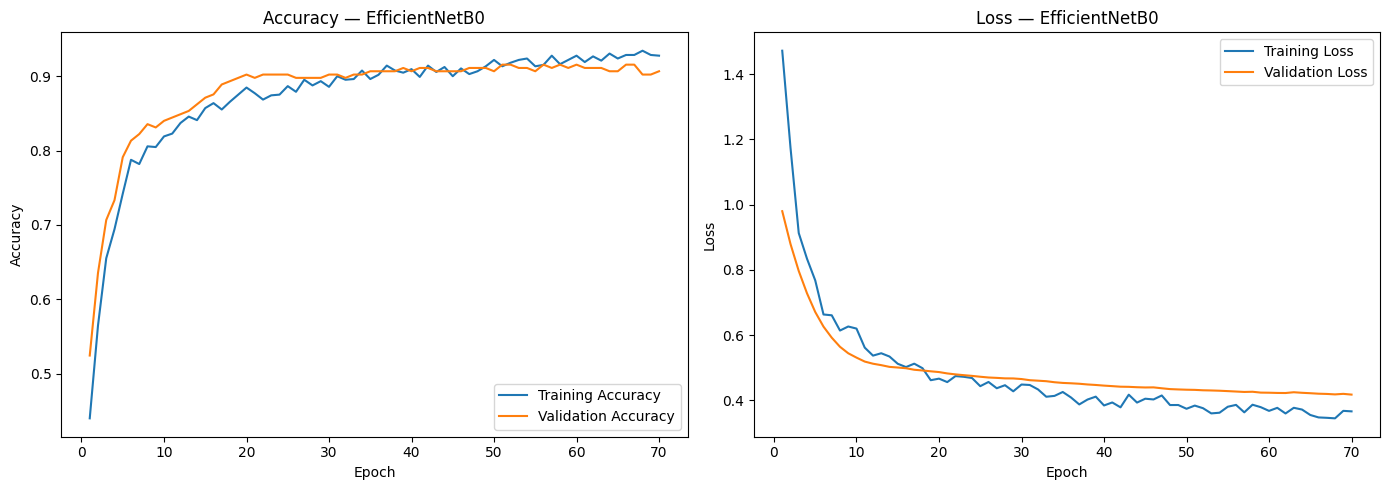

In [ ]:
# 9.3 VISUALISASI HASIL TRAINING DAN VALIDATION
# Grafik accuracy dan loss digunakan untuk melihat perkembangan performa
# training serta indikasi overfitting dari perbedaan kurva validation.

def plot_training_history(history, title):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(f"Accuracy — {title}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(f"Loss — {title}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Tampilkan kurva training dan validation untuk kedua model.
plot_training_history(mobilenet_history, "MobileNetV3-Large")
plot_training_history(efficientnet_history, "EfficientNetB0")

In [ ]:
# 10. TESTING DAN EVALUASI MODEL
# Dataset test hanya digunakan di tahap akhir untuk mengukur kemampuan
# generalisasi model terbaik. Metrik: accuracy, precision, recall, F1-score,
# classification report, dan confusion matrix.

def test_and_evaluate_model(model, model_name, dataset):
    print("=" * 60)
    print(f"Testing dan evaluasi: {model_name}")
    print("=" * 60)

    test_loss, test_accuracy = model.evaluate(dataset, verbose=1)
    y_true, y_pred = [], []

    for images, labels in dataset:
        probabilities = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(probabilities, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    print(f"Test Loss     : {test_loss:.4f}")
    print(f"Test Accuracy : {test_accuracy:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1-Score      : {f1_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Epoch": EPOCHS,
        "Learning Rate": LEARNING_RATE,
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1_score,
    }


Testing dan evaluasi: MobileNetV3-Large
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9067 - loss: 0.3914
Test Loss     : 0.3914
Test Accuracy : 0.9067
Precision     : 0.9068
Recall        : 0.9067
F1-Score      : 0.9067

Classification Report:
                 precision    recall  f1-score   support

Setengah Matang       0.86      0.87      0.86        75
         Matang       0.89      0.88      0.89        75
         Mentah       0.97      0.97      0.97        75

       accuracy                           0.91       225
      macro avg       0.91      0.91      0.91       225
   weighted avg       0.91      0.91      0.91       225



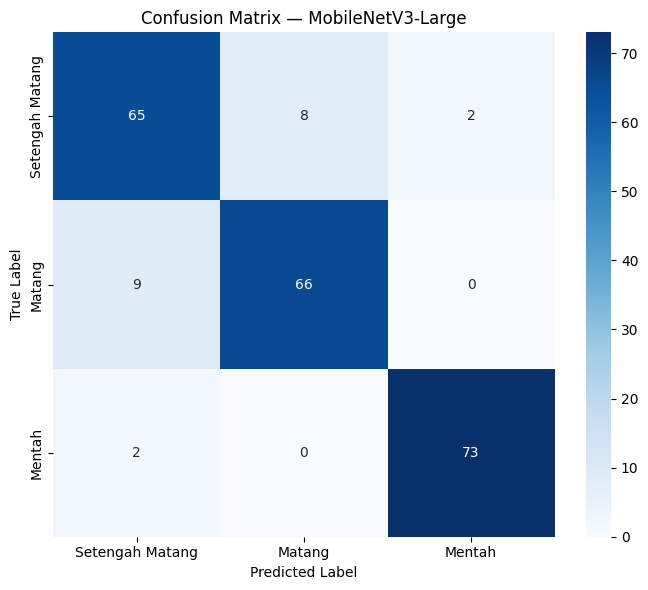

In [ ]:
# 10.1 TESTING — MODEL 1: MOBILENETV3-LARGE
mobilenet_result = test_and_evaluate_model(
    mobilenet_model,
    "MobileNetV3-Large",
    test_ds,
)

Testing dan evaluasi: EfficientNetB0
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9467 - loss: 0.3246
Test Loss     : 0.3246
Test Accuracy : 0.9467
Precision     : 0.9465
Recall        : 0.9467
F1-Score      : 0.9465

Classification Report:
                 precision    recall  f1-score   support

Setengah Matang       0.93      0.91      0.92        75
         Matang       0.92      0.93      0.93        75
         Mentah       0.99      1.00      0.99        75

       accuracy                           0.95       225
      macro avg       0.95      0.95      0.95       225
   weighted avg       0.95      0.95      0.95       225



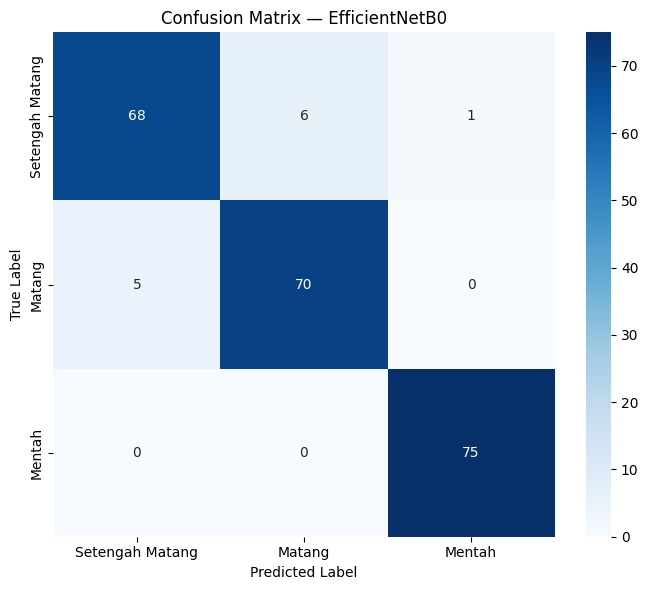

In [ ]:
# 10.2 TESTING — MODEL 2: EFFICIENTNETB0
efficientnet_result = test_and_evaluate_model(
    efficientnet_model,
    "EfficientNetB0",
    test_ds,
)

In [ ]:
# 11. PERFORMANCE METRICS DAN COMPARISON OF MODEL PERFORMANCE
# Tabel merangkum metrik testing kedua model untuk memudahkan perbandingan.

results_df = pd.DataFrame([mobilenet_result, efficientnet_result])
metrics_to_convert = ["Test Accuracy", "Precision", "Recall", "F1-Score"]

for metric in metrics_to_convert:
    results_df[metric] = (results_df[metric] * 100).map("{:.2f}%".format)

display(results_df)

,Model,Epoch,Learning Rate,Test Loss,Test Accuracy,Precision,Recall,F1-Score
0,MobileNetV3-Large,70,0.0001,0.391360,90.67%,90.68%,90.67%,90.67%
1,EfficientNetB0,70,0.0001,0.324555,94.67%,94.65%,94.67%,94.65%


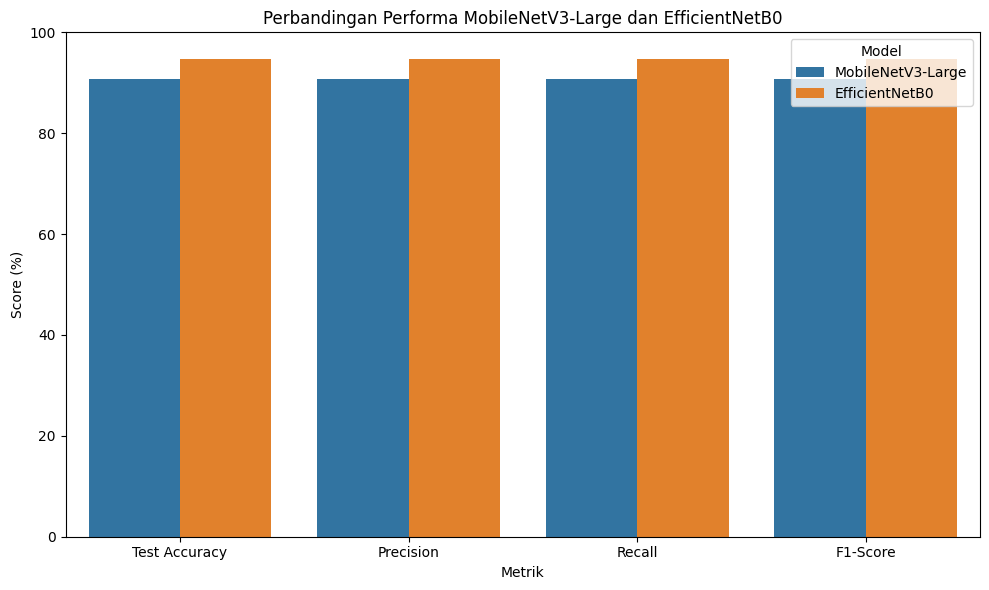

In [ ]:
# 11.1 VISUALISASI PERBANDINGAN PERFORMA MODEL
# Grafik batang menampilkan perbandingan metrik utama dalam satu skala persentase.

metrics_to_plot = ["Test Accuracy", "Precision", "Recall", "F1-Score"]
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score",
)
results_melted["Score"] = results_melted["Score"].str.rstrip("%").astype(float)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model")
plt.ylim(0, 100)
plt.ylabel("Score (%)")
plt.xlabel("Metrik")
plt.title("Perbandingan Performa MobileNetV3-Large dan EfficientNetB0")
plt.legend(title="Model")
plt.tight_layout()
plt.show()